# Simple LangGraph Workflow
- Notebook by Adam Lang
- Date: August 7, 2026

## Overview
- This is a basic overview of a simple LangGraph workflow as a review to build upon. 

## State
- First we need to define the State of the graph. 
- The State schema serves as the input schema for all NODES and EDGES in the graph. 
- We will use the `TypedDict` class from pythons typing module as our schema which provides the keys.

In [1]:
from typing_extensions import TypedDict ## anything in graph should be created in dictionary format

class State(TypedDict):
    graph_info: str # info 

In [10]:
## create starting node 
def start_play(state:State):
    print("Start play node has been called")
    return {"graph_info": state["graph_info"] + "I am planning to play "} # return state with updated graph_info

## create Tennis node #2
def tennis(state:State):
    print("Tennis node has been called")
    return {"graph_info": state["graph_info"] + "Tennis"} # return state with updated graph_info

## create Basketball node #3
def basketball(state:State):
    print("Basketball node has been called")
    return {"graph_info": state["graph_info"] + "Basketball"} # return state with updated graph_info for basketball



### Conditional Nodes

In [11]:
import random
from typing import Literal 

## create conditional node
def random_play(state:State)-> Literal['tennis','basketball']:
    if random.random() < 0.5:
        return "tennis"
    else:
        return "basketball"

## Construct Entire Graph (DAG)

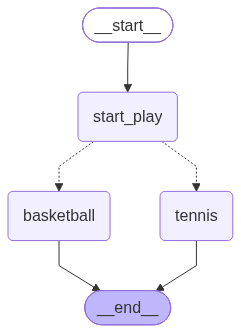

In [12]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## Build graph
graph = StateGraph(State)

## add all nodes to graph
graph.add_node("start_play", start_play) ## node name, function name
graph.add_node("tennis", tennis)
graph.add_node("basketball", basketball)

## Schedule the flow of the graph
graph.add_edge(START, "start_play") ## start node to start_play node
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("tennis", END) ## end node to tennis node
graph.add_edge("basketball", END) ## end node to basketball node

## Compile the graph -- before running 
graph_builder = graph.compile()

## View the graph
display(Image(graph_builder.get_graph().draw_mermaid_png())) ## display the graph in notebook

## Invoke

In [14]:
graph_builder.invoke({"graph_info": "My name is Bluey. "})

Start play node has been called
Tennis node has been called


{'graph_info': 'My name is Bluey. I am planning to play Tennis'}